In [3]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math

path_google = 'G:/Shared drives/'

def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galO_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label


def make_binary_model_OB(p): # OB pair
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label

Reading and plotting spectrum

Found 3 observations for HD23625:
hd23625_2004924pnm_rn.s
hd23625_E_1650068pnm_rn.s
hd23625_E_2004924pnm_rn.s


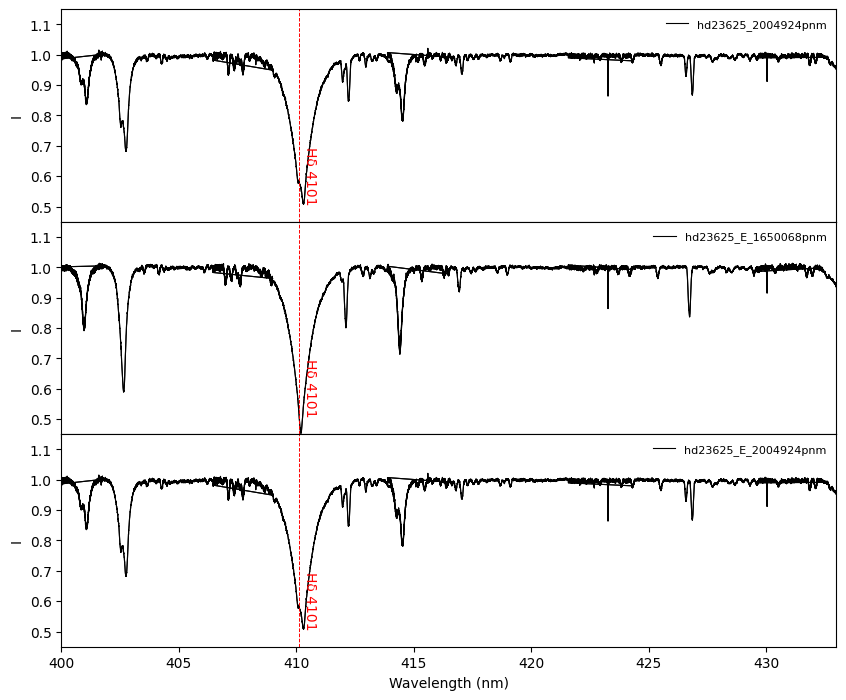

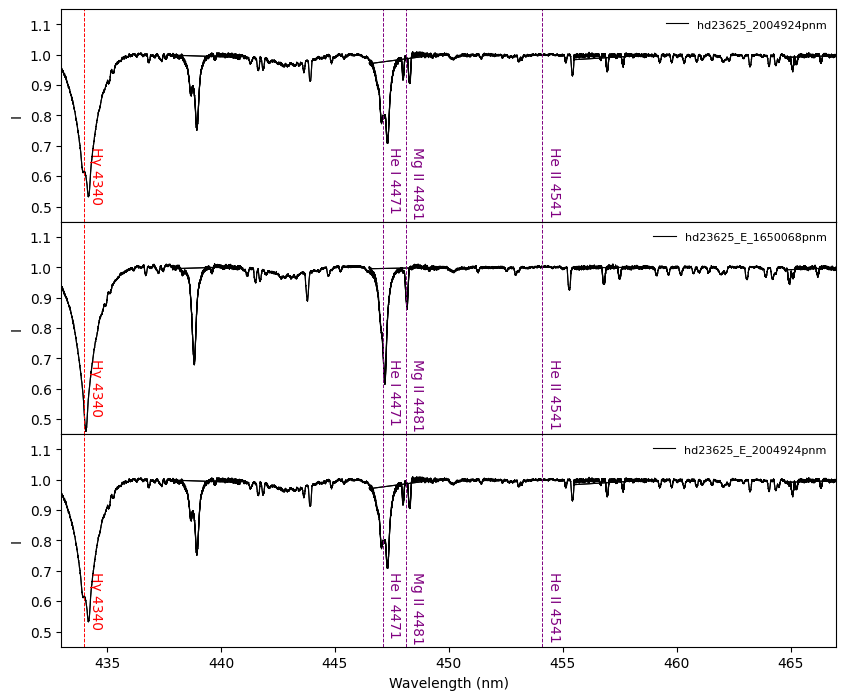

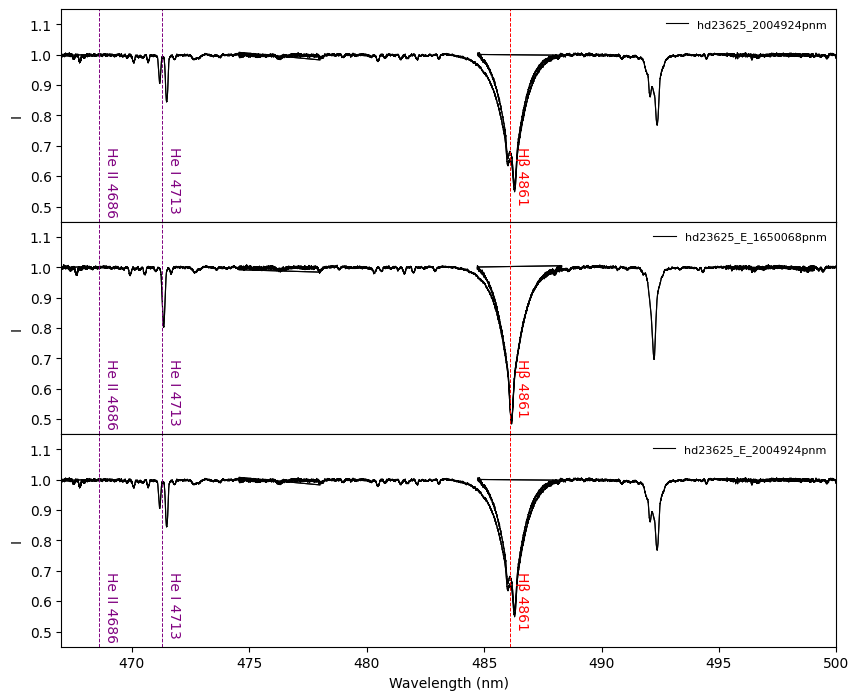

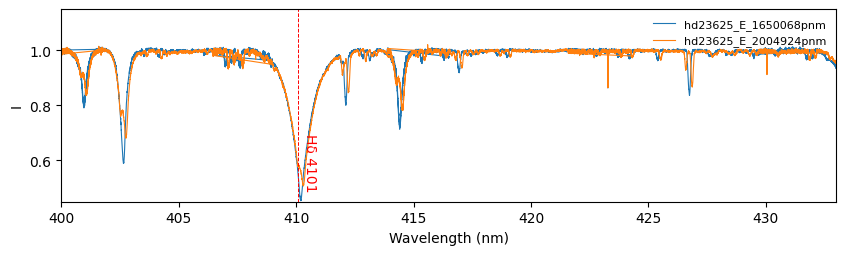

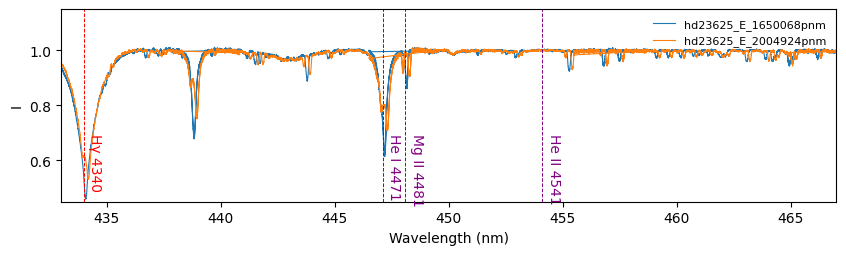

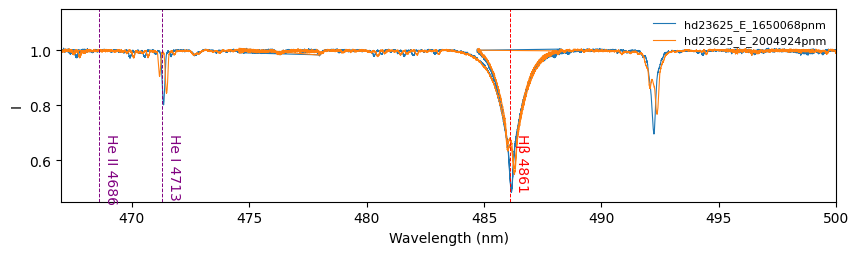

In [10]:
# "G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero/hd23625_2004924pnm_rn.s"

obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")

hd = "HD23625"      # Change this to whichever star you want

obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

print(f"Found {len(obs)} observations for {hd}:")
for f in obs:
    print(f)


windows = [
    (400, 433),
    (433, 467),
    (467, 500),
]

lines_H = [
    (410.1, 'Hδ 4101'),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
]
spectra = []
for filename in obs:
    spectra.append((filename, pol.read_spectrum(obs_folder / filename)))

for xmin, xmax in windows:

    fig, ax = plt.subplots(
        len(spectra), 1,
        figsize=(10, 2.5 * len(spectra)),
        sharex=True
    )

    # If only one observation
    if len(spectra) == 1:
        ax = [ax]

    for i, (filename, spec) in enumerate(spectra):

        ax[i].plot(spec.wl, spec.specI, lw=0.8, color="black")

        ax[i].set_xlim(xmin, xmax)
        ax[i].set_ylim(0.45, 1.15)

        ax[i].set_ylabel("I")
        label = filename.replace("_rn.s", "")
        ax[i].plot(spec.wl, spec.specI, lw=0.8, color="black", label=label)
        ax[i].legend(loc="upper right", fontsize=8, frameon=False)
        # Hydrogen lines
        for wl, label in lines_H:
            if xmin <= wl <= xmax:
                ax[i].axvline(wl,color='red', ls='--',lw=0.7)

                ax[i].text(wl + 0.5,0.70,label,color='red',fontsize=10,rotation=-90,
                        ha='center',va='top')
        # Helium / metal lines
        for wl, label in lines_He:
            if xmin <= wl <= xmax:
                ax[i].axvline(wl,color='purple',ls='--',lw=0.7)
                ax[i].text(wl + 0.5,0.70,label,color='purple',fontsize=10,rotation=-90,
                        ha='center',va='top')



    ax[-1].set_xlabel("Wavelength (nm)")
    fig.subplots_adjust(hspace=0, top=0.93, bottom=0.08)
    plt.show()

def plot_two_obs(filename1, filename2):

    spec1 = pol.read_spectrum(obs_folder / filename1)
    spec2 = pol.read_spectrum(obs_folder / filename2)

    spectra = [(filename1, spec1), (filename2, spec2)]

    for xmin, xmax in windows:
        fig, ax = plt.subplots(figsize=(10, 2.5))

        for filename, spec in spectra:
            label = filename.replace("_rn.s", "")
            ax.plot(spec.wl, spec.specI, lw=0.8, label=label)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0.45, 1.15)
        ax.set_ylabel("I")
        ax.set_xlabel("Wavelength (nm)")
        ax.legend(loc="upper right", fontsize=8, frameon=False)

        for wl, label in lines_H:
            if xmin <= wl <= xmax:
                ax.axvline(wl, color="red", ls="--", lw=0.7)
                ax.text(wl+0.5, 0.70, label, color="red", fontsize=10,
                        rotation=-90, ha="center", va="top")

        for wl, label in lines_He:
            if xmin <= wl <= xmax:
                ax.axvline(wl, color="purple", ls="--", lw=0.7)
                ax.text(wl+0.5, 0.70, label, color="purple", fontsize=10,
                        rotation=-90, ha="center", va="top")

        plt.show()

plot_two_obs("hd23625_E_1650068pnm_rn.s", "hd23625_E_2004924pnm_rn.s")


Another individual block for sorting only

In [6]:
hd = "hd25204"      # Change this to whichever star you want

obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

print(f"Found {len(obs)} observations for {hd}:")
for f in obs:
    print(f)
print(obs)
name = obs[0]
spec = pol.read_spectrum(obs_folder / f"{name}")

Found 3 observations for hd25204:
hd25204_E_1019847pn_rn.s
hd25204a_N_150226pn_rn.s
hd25204a_N_150562pn_rn.s
['hd25204_E_1019847pn_rn.s', 'hd25204a_N_150226pn_rn.s', 'hd25204a_N_150562pn_rn.s']


In [7]:
def dopplershift_rotate(spectrum, dopplershift, vsini):
    """Apply radial-velocity shift followed by rotational broadening."""
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    broadened_spectrum = shifted_spectrum.convolveRot(vsini, 0.5)
    return broadened_spectrum


def make_single_model(params):

    grid = params["grid"].upper()

    if grid == "B":
        path_template = vp.tlusty.galB_path_name
    elif grid == "O":
        path_template = vp.tlusty.galO_path_name
    else:
        raise ValueError(
            f"Unknown grid {params['grid']!r}. "
            "Expected 'B' or 'O'."
        )

    model_path = path_template.format(
        "vis",
        params["teff"],
        params["logg"],
        str(params["vturb"]),
    )

    full_model_path = path_google + model_path

    model = vp.tlusty.read_norm(full_model_path)

    model = dopplershift_rotate(
        spectrum=model,
        dopplershift=params["vrad"],
        vsini=params["vsini"],
    )

    return model
# def make_binary_components(params):
#     """
#     Generate the two binary components separately.
#     """

#     params_1 = {
#         "grid": params["grid_1"],
#         "teff": params["teff1"],
#         "logg": params["logg1"],
#         "vsini": params["vsini1"],
#         "vrad": params["vrad1"],
#         "vturb": params.get("vturb1", params["vturb"]),
#     }

#     params_2 = {
#         "grid": params["grid_2"],
#         "teff": params["teff2"],
#         "logg": params["logg2"],
#         "vsini": params["vsini2"],
#         "vrad": params["vrad2"],
#         "vturb": params.get("vturb2", params["vturb"]),
#     }

#     component_1 = make_single_model(params_1)
#     component_2 = make_single_model(params_2)

#     label_1 = (
#         rf"Component 1 ({params_1['grid']}-grid): "
#         rf"$T_{{\rm eff}}={params_1['teff']}$ K, "
#         rf"$\log g={params_1['logg'] / 100:.2f}$, "
#         rf"$v\sin i={params_1['vsini']}$ km s$^{{-1}}$, "
#         rf"$v_r={params_1['vrad']}$ km s$^{{-1}}$"
#     )

#     label_2 = (
#         rf"Component 2 ({params_2['grid']}-grid): "
#         rf"$T_{{\rm eff}}={params_2['teff']}$ K, "
#         rf"$\log g={params_2['logg'] / 100:.2f}$, "
#         rf"$v\sin i={params_2['vsini']}$ km s$^{{-1}}$, "
#         rf"$v_r={params_2['vrad']}$ km s$^{{-1}}$"
#     )

#     return component_1, component_2, label_1, label_2

def make_binary_components(params):
    """
    Generate the two stellar contributions to the normalized binary spectrum
    based on star_1 = F1/(C1+C2(R2R1**2)) and star_2 = F2 * R2R1**2/(C1+C2(R2R1**2)).
    """


    if params["grid_1"].upper() == "B":
        path_template_1 = vp.tlusty.galB_path_name
    elif params["grid_1"].upper() == "O":
        path_template_1 = vp.tlusty.galO_path_name
    else:
        raise ValueError("grid_1 must be 'B' or 'O'")

    if params["grid_2"].upper() == "B":
        path_template_2 = vp.tlusty.galB_path_name
    elif params["grid_2"].upper() == "O":
        path_template_2 = vp.tlusty.galO_path_name
    else:
        raise ValueError("grid_2 must be 'B' or 'O'")

    vturb1 = params.get("vturb1", params["vturb"])
    vturb2 = params.get("vturb2", params["vturb"])

    model_path_1 = path_template_1.format("vis",params["teff1"],params["logg1"],str(vturb1))
    model_path_2 = path_template_2.format("vis",params["teff2"],params["logg2"],str(vturb2))

    synth1, synth1_con = vp.tlusty.read(path_google + model_path_1) 
    synth2, synth2_con = vp.tlusty.read(path_google + model_path_2)

    wl = synth1.wl

    # Star 1
    shifted1 = synth1.doppler_shift(params["vrad1"])
    shifted1_con = synth1_con.doppler_shift(params["vrad1"])

    interp1 = shifted1.interp(wl) 
    interp1_con = shifted1_con.interp(wl)

    broad1 = interp1.rot_int_cmj(vsini=params["vsini1"])

    broad1_con = interp1_con.rot_int_cmj(vsini=params["vsini1"])


    # Star 2
    shifted2 = synth2.doppler_shift(params["vrad2"])
    shifted2_con = synth2_con.doppler_shift(params["vrad2"])

    interp2 = shifted2.interp(wl)
    interp2_con = shifted2_con.interp(wl)

    broad2 = interp2.rot_int_cmj(
        vsini=params["vsini2"]
    )

    broad2_con = interp2_con.rot_int_cmj(
        vsini=params["vsini2"]
    )

    R2R1 = params["R2R1"]

    total_continuum = (broad1_con.specI+ broad2_con.specI * R2R1**2) # denominator

    contribution_1 = (broad1.specI / total_continuum)

    contribution_2 = (broad2.specI * R2R1**2 / total_continuum)


    continuum_1 = (broad1_con.specI/ total_continuum)

    continuum_2 = (broad2_con.specI * R2R1**2/total_continuum)

    contribution_1_shifted = (contribution_1+ (1 - continuum_1))

    contribution_2_shifted = (contribution_2+ (1 -continuum_2)  )
    
    component_1 = vp.synth.Synth(wl,contribution_1_shifted)

    component_2 = vp.synth.Synth(wl, contribution_2_shifted)



    label_1 = (
        rf"Component 1 ({params['grid_1']}-grid): "
        rf"$T_{{\rm eff}}={params['teff1']}$ K, "
        rf"$\log g={params['logg1'] / 100:.2f}$, "
        rf"$v\sin i={params['vsini1']}$ km s$^{{-1}}$, "
        rf"$v_r={params['vrad1']}$ km s$^{{-1}}$"
    )

    label_2 = (
        rf"Component 2 ({params['grid_2']}-grid): "
        rf"$T_{{\rm eff}}={params['teff2']}$ K, "
        rf"$\log g={params['logg2'] / 100:.2f}$, "
        rf"$v\sin i={params['vsini2']}$ km s$^{{-1}}$, "
        rf"$v_r={params['vrad2']}$ km s$^{{-1}}$"
    )

    return component_1, component_2, label_1, label_2
def plot_component(components):
    fig, ax = plt.subplots(len(windows), 1, figsize=(8, 2.5 * len(windows)), sharex=False, sharey=True)

    for i, (xmin, xmax) in enumerate(windows):
        a = ax[i]
        a.plot(spec.wl, spec.specI, color="grey", lw=3, label="Observed")

        for j, (component, label) in enumerate(components):
            a.plot(component.wl/10, component.specI, lw=1, label=f"Component {j+1}")

        a.set_xlim(xmin, xmax)
        a.set_ylim(0.4, 1.05)
        a.set_ylabel("Stokes I")

        if i == len(windows)-1:
            a.set_xlabel("Wavelength (nm)")

        for wl, text in lines_H:
            if xmin <= wl <= xmax:
                a.axvline(wl, color="red", ls="--", lw=0.7)
                a.text(wl+0.3, 0.70, text, color="red", rotation=-90, va="top", fontsize=9)

        for wl, text in lines_He:
            if xmin <= wl <= xmax:
                a.axvline(wl, color="purple", ls="--", lw=0.7)
                a.text(wl+0.3, 0.70, text, color="purple", rotation=-90, va="top", fontsize=9)

        if i == 0:
            a.legend(frameon=False, fontsize=8)

    fig.suptitle(name, fontsize=14, y=0.98)
    fig.tight_layout()
    plt.show()

In [8]:
name = obs[0]
spec = pol.read_spectrum(obs_folder / f"{name}")
print(name)
params_B = {
    "grid_1":"B", "grid_2":"B",
    "teff1": 15000, "logg1":350,
    "teff2": 15000, "logg2":350,
    "vsini1": 40, "vsini2": 50,
    "vrad1": -120, "vrad2": 80,
    "R2R1":1.5,
    "vturb": 2,
}


hd25204_E_1019847pn_rn.s


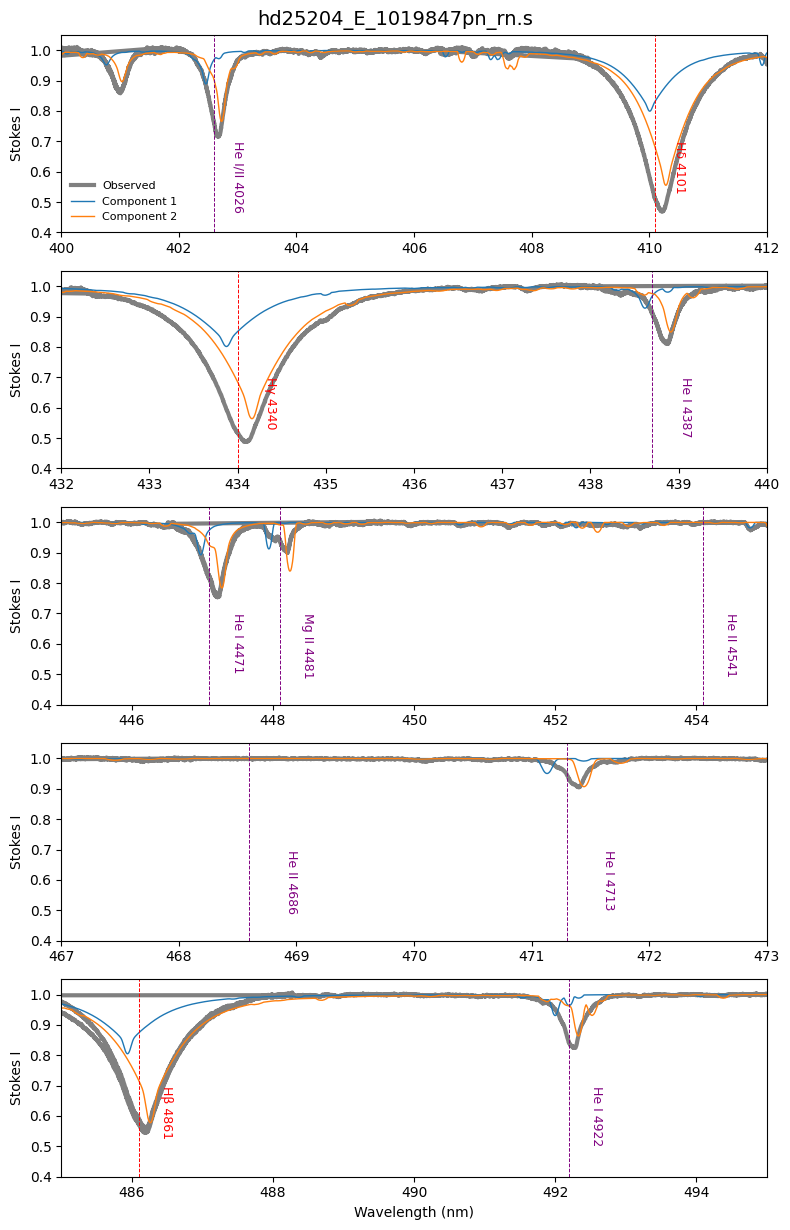

In [9]:
component_1, component_2, label_1, label_2 = (
    make_binary_components(params_B)
)

components = [
    (component_1, label_1),
    (component_2, label_2),
]
windows = [
    (400, 412),
    (432, 440),
    (445, 455),
    (467, 473),
    (485, 495)
]

lines_H = [
    (410.1, "Hδ 4101"),
    (434.0, "Hγ 4340"),
    (486.1, "Hβ 4861"),
]

lines_He = [
    (402.6, "He I/II 4026"),
    (420.0, "He II 4200"),
    (438.7, "He I 4387"),
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
    (492.2, "He I 4922"),
    (501.6, "He I 5016"),
    (580.1, "C IV 5801"),
    (581.1, "C IV 5811"),
]
plot_component(components)
# plot_component(component_2, label_2)